# Part 2 – Demand forecasting: model comparison & selection (v1.0)
Armani Middle East Trading technical assessment · **Part 2, step 2: forecast the next 26 weeks of demand**

**Target:** reconstructed weekly demand `demand_est` (see `part2_preprocessing_v1.0.ipynb`) for each of the 30 products, weeks 261–286.

**Approaches compared** (all evaluated on the same rolling-origin backtests):
| Code | Approach | Free parameters (tuned on training data only) |
|---|---|---|
| `snaive`, `mean52`, `idx52` | Baselines: same week last year / last-52-week mean / mean × shared seasonal index | – |
| `ets` | Holt-Winters per product | smoothing parameters by MLE; trend/seasonal type by AICc |
| `sarimax` | Regression with Fourier seasonality + ARMA errors per product | Fourier order, ARMA order by AICc; coefficients by MLE |
| `struct` | **Shared-curve structural model** (pooled, log-linear) | Fourier order K, trend structure – inner time-series CV |
| `struct_seg` | Same, fitted separately per segment (7 high-stock / 23 normal) – *cluster approach* | K, trend per segment |
| `lgbm` | Global LightGBM (direct multi-horizon) | leaves, learning rate, min leaf, feature fraction, L2, #trees – validation block |
| `lgbm_seg` | LightGBM per segment – *cluster approach* | same |
| `prophet` | Prophet per product | changepoint prior, Fourier order, seasonality mode – inner time-series CV |
| `ens_mean`, `ens_wf` | Ensembles: equal-weight mean of 5 pre-declared models / walk-forward top-3 | – |

**Validation:** 4 rolling origins (train weeks 1..156, 182, 208, 234 → test the next 26 weeks), then a final fit on all 260 weeks. **Every free parameter is chosen inside the training window** (inner time-series CV or a trailing validation block); the test windows are never used for tuning. Metrics: MAE, RMSE, MAPE, WAPE, MASE, bias – on reconstructed demand *and* on the "truth" subset (unconstrained weeks where demand = observed sales).

In [1]:
import itertools
import logging
import os
import sqlite3
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import statsmodels.api as sm
from joblib import Parallel, delayed
from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

%matplotlib inline
warnings.filterwarnings("ignore")
for _n in ("cmdstanpy", "prophet"):
    logging.getLogger(_n).setLevel(logging.CRITICAL)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, GREY, RED, GREEN, PURPLE = "#2c7fb8", "#e08214", "#7f7f7f", "#c0392b", "#2e8b57", "#7b5ea7"

VERSION = "v1.0"                          # appended to the name of every generated file
HERE = Path.cwd()
DB_IN = HERE / "part2_preprocessing_v1.0" / "forecast_dataset_v1.0.db"
OUT = HERE / "part2_forecasting_v1.0"     # created by this notebook
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
DB_OUT = OUT / f"forecast_results_{VERSION}.db"
XLSX_PATH = OUT / f"forecast_results_{VERSION}.xlsx"

H = 26                                    # forecast horizon (weeks)
ORIGINS = [156, 182, 208, 234]            # rolling-origin backtests (train = weeks 1..origin)
FINAL = 260                               # final fit on all data -> weeks 261..286
N_JOBS = max(1, min(8, os.cpu_count() or 1))
SEED = 42
rng = np.random.default_rng(SEED)
START = pd.Timestamp("2020-01-06")        # synthetic calendar (same assumption as ETL / preprocessing)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## 1. Load the forecasting dataset

In [2]:
if not DB_IN.exists():
    raise FileNotFoundError(f"{DB_IN} not found - run part2_preprocessing_v1.0.ipynb first")
con = sqlite3.connect(DB_IN)
panel = pd.read_sql("SELECT * FROM demand_panel", con).sort_values(["product_id", "week_id"])
prod_profile = pd.read_sql("SELECT * FROM product_profile", con)
cal_future = pd.read_sql("SELECT * FROM calendar_future", con)
last_known = pd.read_sql("SELECT * FROM last_known", con)
con.close()

pids = np.sort(panel.product_id.unique()); NP = len(pids)
pinfo = panel.drop_duplicates("product_id").set_index("product_id").loc[pids]
names = pinfo.product_name.values
seg = pinfo.inventory_profile.values                   # 'high_stock' (7) / 'normal' (23)
piv = lambda col: panel.pivot(index="week_id", columns="product_id", values=col).reindex(columns=pids)
Y = piv("demand_est").values                           # (260, 30) target
SALES = piv("sales_units").values
STOCK = piv("stock_available_for_sales").values
PRICE = piv("unit_price").values
COGS = piv("unit_cogs").values
UNC = (piv("censor_status") == "unconstrained").values  # True where demand_est == observed sales (truth cells)
STATIC = np.column_stack([np.arange(NP), pd.factorize(seg)[0], pd.factorize(pinfo.stock_regime.values)[0], pd.factorize(pinfo.product_category.values)[0]])
assert Y.shape == (260, 30) and np.isfinite(Y).all() and (Y > 0).all()
print(f"demand matrix {Y.shape} | segments: {pd.Series(seg).value_counts().to_dict()} | jobs={N_JOBS}")

woy = lambda w: (np.asarray(w) - 1) % 52 + 1
ds_of = lambda w: START + pd.to_timedelta((np.asarray(w) - 1) * 7, unit="D")

demand matrix (260, 30) | segments: {'normal': 23, 'high_stock': 7} | jobs=4


## 2. Metrics helpers

In [3]:
def wape(a, f):
    return float(np.abs(a - f).sum() / np.sum(a))


def tmax_scale(T):
    """MASE denominator per product: in-sample mean |y_t - y_{t-52}| on the training window."""
    return np.mean(np.abs(Y[52:T] - Y[:T - 52]), axis=0)

## 3. Models
Every model is a function `model(T) -> (forecast[H, 30], info)` that only uses `Y[:T]`.
### 3.1 Baselines

In [4]:
def m_snaive(T):
    return Y[T - 52:T - 52 + H].copy(), "same week last year"


def m_mean52(T):
    return np.tile(Y[T - 52:T].mean(0), (H, 1)), "mean of last 52 weeks"


def shared_index(T):
    """Shared seasonal index (52 values): product-year-normalised demand averaged over products and full years."""
    idx, cnt = np.zeros(52), np.zeros(52)
    for k in range(T // 52):
        blk = Y[T - 52 * (k + 1):T - 52 * k]
        wo = (np.arange(T - 52 * (k + 1) + 1, T - 52 * k + 1) - 1) % 52
        np.add.at(idx, wo, (blk / blk.mean(0)).mean(1)); np.add.at(cnt, wo, 1)
    return idx / cnt


def m_idx52(T):
    idx = shared_index(T)
    return Y[T - 52:T].mean(0)[None, :] * idx[woy(np.arange(T + 1, T + H + 1)) - 1][:, None], "last-52 mean x shared seasonal index"

### 3.2 Per-product statistical models (ETS, SARIMAX) – structure chosen by AICc on the training window

In [5]:
def _ets_one(y):
    best, info = None, "fallback: seasonal naive"
    for trend, damped, seas in [(None, False, "add"), (None, False, "mul"), ("add", True, "add"), ("add", True, "mul")]:
        try:
            fit = ExponentialSmoothing(y, trend=trend, damped_trend=damped, seasonal=seas, seasonal_periods=52,
                                       initialization_method="estimated").fit()
            if best is None or fit.aicc < best[0]:
                best, info = (fit.aicc, fit.forecast(H)), f"trend={trend}, damped={damped}, seasonal={seas}"
        except Exception:
            continue
    return (best[1] if best else y[-52:-52 + H]), info


def m_ets(T):
    res = Parallel(n_jobs=N_JOBS)(delayed(_ets_one)(Y[:T, j]) for j in range(NP))
    return np.column_stack([r[0] for r in res]), "; ".join(sorted({r[1] for r in res}))


def _fourier_trend(w, K):
    a = 2 * np.pi * woy(w)[:, None] * np.arange(1, K + 1)[None, :] / 52
    return np.hstack([np.sin(a), np.cos(a), ((np.asarray(w) - 130) / 260.0)[:, None]])


def _sarimax_one(y, T):
    best = None
    for K, order in itertools.product([2, 3], [(1, 0, 0), (1, 0, 1)]):
        try:
            res = SARIMAX(np.log(y), exog=_fourier_trend(np.arange(1, T + 1), K), order=order).fit(disp=False, maxiter=150)
            if best is None or res.aicc < best[0]:
                smear = np.exp(np.var(res.resid[10:]) / 2)
                f = np.exp(res.forecast(H, exog=_fourier_trend(np.arange(T + 1, T + H + 1), K))) * smear
                best = (res.aicc, f, f"K={K}, order={order}")
        except Exception:
            continue
    return (best[1], best[2]) if best else (y[-52:-52 + H], "fallback: seasonal naive")


def m_sarimax(T):
    res = Parallel(n_jobs=N_JOBS)(delayed(_sarimax_one)(Y[:T, j], T) for j in range(NP))
    return np.column_stack([r[0] for r in res]), "; ".join(sorted({r[1] for r in res}))

### 3.3 Shared-curve structural model (pooled) and its per-segment (cluster) variant
`log demand = product level + trend + Σ_k a_k sin + b_k cos (shared by all products in the fit)`. The Fourier order `K` and the trend structure (shared / per product) are **chosen by inner time-series CV on the training window**: two inner origins (`T-52`, `T-26`), horizon 26, criterion WAPE.

In [6]:
def struct_design(w, pi, n, K, mode):
    P = np.zeros((len(w), n)); P[np.arange(len(w)), pi] = 1
    t = ((w - 130) / 260.0)[:, None]
    ang = 2 * np.pi * woy(w)[:, None] * np.arange(1, K + 1)[None, :] / 52
    return np.hstack([P, t * P if mode == "per_product" else t, np.sin(ang), np.cos(ang)])


def struct_fit_forecast(Ytr, T, K, mode):
    n = Ytr.shape[1]
    X = struct_design(np.tile(np.arange(1, T + 1), n), np.repeat(np.arange(n), T), n, K, mode)
    y = np.log(Ytr.T.reshape(-1))
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    smear = np.exp(np.var(y - X @ beta) / 2)
    Xf = struct_design(np.tile(np.arange(T + 1, T + H + 1), n), np.repeat(np.arange(n), H), n, K, mode)
    return (np.exp(Xf @ beta) * smear).reshape(n, H).T


STRUCT_GRID = list(itertools.product(range(1, 9), ["shared", "per_product"]))


def struct_tune_forecast(T, cols):
    Ysub = Y[:, cols]
    scores = {}
    for K, mode in STRUCT_GRID:
        scores[(K, mode)] = np.mean([wape(Ysub[o:o + H], struct_fit_forecast(Ysub[:o], o, K, mode)) for o in (T - 52, T - 26)])
    (K, mode) = min(scores, key=scores.get)
    return struct_fit_forecast(Ysub[:T], T, K, mode), f"K={K}, trend={mode} (inner CV WAPE {scores[(K, mode)]:.4f})"


def m_struct(T):
    return struct_tune_forecast(T, np.arange(NP))


def m_struct_seg(T):
    fc, info = np.zeros((H, NP)), []
    for g in ("high_stock", "normal"):
        cols = np.where(seg == g)[0]
        f, i = struct_tune_forecast(T, cols); fc[:, cols] = f; info.append(f"{g}: {i}")
    return fc, " | ".join(info)

### 3.4 Global LightGBM (direct multi-horizon) and its per-segment variant
One row per (origin, horizon, product): features known at the origin only – horizon, week-of-year (+ sin/cos), trend index, last-year demand (same week and ±1), recent levels (13/26/52-week means), product/segment/regime/category codes. The target is demand relative to the 52-week level. **Hyper-parameters are chosen on a trailing validation block inside the training window** (rows whose targets lie in the last 26 training weeks), then the model is refitted on all training rows.

In [7]:
FEAT = ["h", "woy", "sin1", "cos1", "sin2", "cos2", "sin3", "cos3", "t", "ly_rel", "ly_nb_rel", "lvl13_rel", "lvl26_rel", "last_rel", "log_lvl52",
        "product", "segment", "regime", "category"]
CAT_IDX = [FEAT.index(c) for c in ("product", "segment", "regime", "category")]


def lgb_feats(o, hs, cols):
    Ys = Y[:, cols]; n = len(cols)
    l52, l26, l13, last = Ys[o - 52:o].mean(0), Ys[o - 26:o].mean(0), Ys[o - 13:o].mean(0), Ys[o - 1]
    out = []
    for h in hs:
        s = o + h
        ly, lyn = Ys[s - 53], Ys[s - 54:s - 51].mean(0)
        wo = (s - 1) % 52 + 1; ang = 2 * np.pi * wo * np.arange(1, 4) / 52
        out.append(np.column_stack([np.full(n, h), np.full(n, wo), np.full(n, np.sin(ang[0])), np.full(n, np.cos(ang[0])),
                                    np.full(n, np.sin(ang[1])), np.full(n, np.cos(ang[1])), np.full(n, np.sin(ang[2])), np.full(n, np.cos(ang[2])),
                                    np.full(n, s), ly / l52, lyn / l52, l13 / l52, l26 / l52, last / l52, np.log(l52), STATIC[cols]]))
    return np.vstack(out)


def lgb_dataset(origins, tmax, cols):
    Ys = Y[:, cols]; X, y, lv = [], [], []
    for o in origins:
        hs = [h for h in range(1, H + 1) if o + h <= tmax]
        if not hs:
            continue
        l52 = Ys[o - 52:o].mean(0)
        X.append(lgb_feats(o, hs, cols)); y.append(np.concatenate([Ys[o + h - 1] / l52 for h in hs])); lv.append(np.tile(l52, len(hs)))
    return np.vstack(X), np.concatenate(y), np.concatenate(lv)


_all = list(itertools.product([7, 15, 31], [0.03, 0.08], [20, 80], [0.7, 1.0], [0.0, 5.0]))
LGB_GRID = [_all[i] for i in np.random.default_rng(SEED).choice(len(_all), 10, replace=False)]


def lgb_tune_forecast(T, cols, n_cfg=10):
    n = len(cols)
    Xtr, ytr, _ = lgb_dataset(range(58, T - H + 1, 2), T - H, cols)
    Xv, yv, lv = lgb_dataset([T - H], T, cols)
    actual_v = Y[T - H:T][:, cols]
    best = None
    for (nl, lr, mcs, ff, l2) in LGB_GRID[:n_cfg]:
        params = dict(objective="regression", num_leaves=nl, learning_rate=lr, min_child_samples=mcs, feature_fraction=ff, lambda_l2=l2,
                      verbose=-1, seed=SEED, num_threads=N_JOBS)
        mdl = lgb.train(params, lgb.Dataset(Xtr, ytr, categorical_feature=CAT_IDX), num_boost_round=1500,
                        valid_sets=[lgb.Dataset(Xv, yv, categorical_feature=CAT_IDX)], callbacks=[lgb.early_stopping(50, verbose=False)])
        sc = wape(actual_v, (mdl.predict(Xv, num_iteration=mdl.best_iteration) * lv).reshape(H, n))
        if best is None or sc < best[0]:
            best = (sc, params, mdl.best_iteration)
    sc, params, bi = best
    Xall, yall, _ = lgb_dataset(range(58, T, 2), T, cols)
    mdl = lgb.train(params, lgb.Dataset(Xall, yall, categorical_feature=CAT_IDX), num_boost_round=int(bi * 1.15) + 1)
    l52 = Y[T - 52:T][:, cols].mean(0)
    fc = (mdl.predict(lgb_feats(T, range(1, H + 1), cols)).reshape(H, n)) * l52[None, :]
    info = f"leaves={params['num_leaves']}, lr={params['learning_rate']}, min_leaf={params['min_child_samples']}, ff={params['feature_fraction']}, l2={params['lambda_l2']}, trees={int(bi * 1.15) + 1} (val WAPE {sc:.4f})"
    return fc, info, mdl


def m_lgbm(T):
    fc, info, mdl = lgb_tune_forecast(T, np.arange(NP)); m_lgbm.last_model = mdl
    return fc, info


def m_lgbm_seg(T):
    fc, info = np.zeros((H, NP)), []
    for g in ("high_stock", "normal"):
        cols = np.where(seg == g)[0]
        f, i, _ = lgb_tune_forecast(T, cols, n_cfg=6); fc[:, cols] = f; info.append(f"{g}: {i}")
    return fc, " | ".join(info)

### 3.5 Prophet per product
Yearly seasonality only (period = 364 days = 52 weeks on the synthetic weekly calendar). Hyper-parameters (changepoint prior scale, Fourier order, seasonality mode) are **chosen by inner time-series CV** (origins `T-52`, `T-26`, horizon 26) on a stratified subset of 6 products (3 high-stock + 3 normal), then applied to all 30 products.

In [8]:
PROPHET_GRID = list(itertools.product([0.01, 0.1], [2, 4], ["additive", "multiplicative"]))
_hs, _nm = np.where(seg == "high_stock")[0], np.where(seg == "normal")[0]
TUNE_PRODS = list(_hs[np.linspace(0, len(_hs) - 1, 3).astype(int)]) + list(_nm[np.linspace(0, len(_nm) - 1, 3).astype(int)])


def _prophet_one(y, T, cps, K, mode):
    for _n in ("cmdstanpy", "prophet"):
        logging.getLogger(_n).setLevel(logging.CRITICAL)
    m = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, changepoint_prior_scale=cps,
                seasonality_mode=mode, uncertainty_samples=0)
    m.add_seasonality(name="yearly", period=364, fourier_order=K)
    m.fit(pd.DataFrame({"ds": ds_of(np.arange(1, T + 1)), "y": y[:T]}))
    return m.predict(pd.DataFrame({"ds": ds_of(np.arange(T + 1, T + H + 1))})).yhat.values


def m_prophet(T):
    jobs = [(c, j, o) for c in range(len(PROPHET_GRID)) for j in TUNE_PRODS for o in (T - 52, T - 26)]
    preds = Parallel(n_jobs=N_JOBS)(delayed(_prophet_one)(Y[:, j], o, *PROPHET_GRID[c]) for c, j, o in jobs)
    sc = {}
    for (c, j, o), p in zip(jobs, preds):
        sc.setdefault(c, []).append(np.abs(Y[o:o + H, j] - p).sum() / Y[o:o + H, j].sum())
    c_best = min(sc, key=lambda c: np.mean(sc[c])); cps, K, mode = PROPHET_GRID[c_best]
    fc = np.column_stack(Parallel(n_jobs=N_JOBS)(delayed(_prophet_one)(Y[:, j], T, cps, K, mode) for j in range(NP)))
    return fc, f"changepoint_prior={cps}, fourier_order={K}, mode={mode} (inner CV WAPE {np.mean(sc[c_best]):.4f})"

## 4. Run all models on every rolling origin (and the final fit)
Each model returns its tuned configuration, which is logged in `Tuned_Params`.

In [9]:
MODELS = {
    "snaive": ("Seasonal naive", m_snaive), "mean52": ("Last-52-week mean", m_mean52), "idx52": ("Mean x shared seasonal index", m_idx52),
    "ets": ("Holt-Winters ETS (per product)", m_ets), "sarimax": ("SARIMAX + Fourier (per product)", m_sarimax),
    "struct": ("Shared-curve structural (pooled)", m_struct), "struct_seg": ("Structural per segment (cluster)", m_struct_seg),
    "lgbm": ("LightGBM global", m_lgbm), "lgbm_seg": ("LightGBM per segment (cluster)", m_lgbm_seg), "prophet": ("Prophet (per product)", m_prophet),
}
LABEL = {k: v[0] for k, v in MODELS.items()}
FC, TUNED, TIMES = {k: {} for k in MODELS}, [], []
t_all = time.time()
for T in ORIGINS + [FINAL]:
    for key, (label, fn) in MODELS.items():
        t0 = time.time()
        fc, info = fn(T)
        assert fc.shape == (H, NP) and np.isfinite(fc).all(), f"{key} @ {T}: bad forecast"
        FC[key][T] = fc; TUNED.append({"model": key, "origin": T, "tuned_configuration": info}); TIMES.append({"model": key, "origin": T, "seconds": round(time.time() - t0, 1)})
    print(f"origin {T} done | elapsed {time.time() - t_all:.0f}s")
last_lgbm_model = m_lgbm.last_model            # LightGBM fitted at the final origin (for feature importance)
tuned = pd.DataFrame(TUNED)
tuned[tuned.origin == FINAL][["model", "tuned_configuration"]]

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params


...

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params


origin 234 done | elapsed 101s


origin 260 done | elapsed 123s


,model,tuned_configuration
40,snaive,same week last year
41,mean52,mean of last 52 weeks
42,idx52,last-52 mean x shared seasonal index
43,ets,"trend=None, damped=False, seasonal=add; trend=..."
44,sarimax,"K=2, order=(1, 0, 1); K=3, order=(1, 0, 1)"
45,struct,"K=3, trend=shared (inner CV WAPE 0.0446)"
46,struct_seg,"high_stock: K=4, trend=shared (inner CV WAPE 0..."
47,lgbm,"leaves=7, lr=0.03, min_leaf=80, ff=0.7, l2=0.0..."
48,lgbm_seg,"high_stock: leaves=7, lr=0.03, min_leaf=20, ff..."
49,prophet,"changepoint_prior=0.01, fourier_order=2, mode=..."


In [10]:
# ensembles: (a) equal-weight mean of 5 pre-declared models, (b) walk-forward top-3 chosen from EARLIER folds only
ENS_MEMBERS = ["ets", "sarimax", "struct", "lgbm", "prophet"]
CANDIDATES = [k for k in MODELS if k not in ("snaive", "mean52", "idx52")]
FC["ens_mean"] = {T: np.mean([FC[m][T] for m in ENS_MEMBERS], axis=0) for T in ORIGINS + [FINAL]}
FC["ens_wf"], wf_sel = {}, {}
for i, T in enumerate(ORIGINS + [FINAL]):
    prev = [o for o in ORIGINS if o < T]
    if not prev:
        FC["ens_wf"][T] = FC["ens_mean"][T]; wf_sel[T] = "all 5 members (no earlier fold)"; continue
    rank = sorted(CANDIDATES, key=lambda m: np.mean([wape(Y[o:o + H], FC[m][o]) for o in prev]))[:3]
    FC["ens_wf"][T] = np.mean([FC[m][T] for m in rank], axis=0); wf_sel[T] = ", ".join(rank)
LABEL.update({"ens_mean": "Ensemble: mean of 5 models", "ens_wf": "Ensemble: walk-forward top-3"})
tuned = pd.concat([tuned, pd.DataFrame([{"model": "ens_wf", "origin": T, "tuned_configuration": f"members: {s}"} for T, s in wf_sel.items()])], ignore_index=True)
pd.DataFrame({"origin": list(wf_sel), "walk-forward top-3 members": list(wf_sel.values())})

,origin,walk-forward top-3 members
0,156,all 5 members (no earlier fold)
1,182,"struct_seg, struct, sarimax"
2,208,"struct_seg, struct, sarimax"
3,234,"struct_seg, struct, sarimax"
4,260,"struct, struct_seg, sarimax"


## 5. Backtest evaluation

In [11]:
def build_backtest():
    rows = []
    for m in FC:
        for T in ORIGINS:
            a, f, u = Y[T:T + H], FC[m][T], UNC[T:T + H]
            rows.append(pd.DataFrame({"model": m, "origin": T, "h": np.repeat(np.arange(1, H + 1), NP), "product_id": np.tile(pids, H),
                                      "week_id": np.repeat(np.arange(T + 1, T + H + 1), NP), "actual": a.ravel(), "forecast": f.ravel(), "unc": u.ravel(),
                                      "scale": np.tile(tmax_scale(T), H)}))
    bt = pd.concat(rows, ignore_index=True)
    bt["segment"] = bt.product_id.map(dict(zip(pids, seg)))
    bt["err"] = bt.forecast - bt.actual; bt["ae"] = bt.err.abs()
    bt["hb"] = pd.cut(bt.h, [0, 4, 13, 26], labels=["h1-4", "h5-13", "h14-26"])
    return bt


def agg_metrics(g):
    return pd.Series({"WAPE": g.ae.sum() / g.actual.sum(), "MAE": g.ae.mean(), "RMSE": np.sqrt((g.err ** 2).mean()), "MAPE_%": 100 * (g.ae / g.actual).mean(),
                      "MASE": (g.ae / g.scale).mean(), "bias_%": 100 * g.err.sum() / g.actual.sum()})


bt = build_backtest()
fold_metrics = bt.groupby(["model", "origin"]).apply(agg_metrics).reset_index()
fold_truth = bt[bt.unc].groupby(["model", "origin"]).apply(agg_metrics).reset_index()
comp = fold_metrics.groupby("model")[["WAPE", "MAE", "RMSE", "MAPE_%", "MASE", "bias_%"]].mean()
comp["WAPE_std_over_folds"] = fold_metrics.groupby("model").WAPE.std()
comp["WAPE_truth_cells"] = fold_truth.groupby("model").WAPE.mean()
comp["MAPE_truth_cells_%"] = fold_truth.groupby("model")["MAPE_%"].mean()
comp["model_name"] = comp.index.map(LABEL)
comp = comp.sort_values("WAPE")
base_best = comp.loc[["snaive", "mean52", "idx52"]].WAPE.min()
comp["skill_vs_best_baseline_%"] = 100 * (1 - comp.WAPE / base_best)
comp["skill_vs_seasonal_naive_%"] = 100 * (1 - comp.WAPE / comp.loc["snaive", "WAPE"])
comp["rank"] = np.arange(1, len(comp) + 1)
comp.round(4)

,WAPE,MAE,RMSE,MAPE_%,MASE,bias_%,WAPE_std_over_folds,WAPE_truth_cells,MAPE_truth_cells_%,model_name,skill_vs_best_baseline_%,skill_vs_seasonal_naive_%,rank
model,,,,,,,,,,,,,
struct,0.0457,96.5460,129.1776,5.0336,0.6871,0.0695,0.0035,0.0664,6.7640,Shared-curve structural (pooled),13.3955,34.2552,1
struct_seg,0.0457,96.5749,129.3420,5.0361,0.6876,0.0234,0.0034,0.0663,6.7757,Structural per segment (cluster),13.3902,34.2512,2
ens_wf,0.0461,97.5519,130.3845,5.0639,0.6940,-0.1346,0.0031,0.0663,6.7674,Ensemble: walk-forward top-3,12.5996,33.6510,3
sarimax,0.0468,98.7795,131.5956,5.1395,0.7022,0.0035,0.0034,0.0674,6.8660,SARIMAX + Fourier (per product),11.3832,32.7276,4
ens_mean,0.0469,99.1673,131.6021,5.1389,0.7055,-0.2783,0.0029,0.0670,6.8369,Ensemble: mean of 5 models,11.1565,32.5555,5
prophet,0.0476,100.4758,133.8027,5.2294,0.7139,0.0739,0.0034,0.0680,6.9663,Prophet (per product),9.8712,31.5797,6
lgbm,0.0478,101.1125,134.5687,5.2434,0.7178,0.0961,0.0029,0.0681,6.9399,LightGBM global,9.4525,31.2619,7
lgbm_seg,0.0490,103.3876,136.2587,5.4653,0.7419,-0.0640,0.0040,0.0703,7.3350,LightGBM per segment (cluster),7.2563,29.5947,8
idx52,0.0528,111.8538,144.8716,5.5582,0.7869,-2.6982,0.0026,0.0681,6.8704,Mean x shared seasonal index,0.0000,24.0861,9


In [12]:
by_seg = bt.groupby(["model", "origin", "segment"]).apply(agg_metrics).reset_index().groupby(["model", "segment"])[["WAPE", "MAE", "MAPE_%", "MASE", "bias_%"]].mean().round(4)
by_hz = bt.groupby(["model", "origin", "hb"]).apply(agg_metrics).reset_index().groupby(["model", "hb"])[["WAPE", "MAE", "MAPE_%", "MASE"]].mean().round(4)
seg_rank = by_seg.WAPE.unstack().rename(columns=lambda c: f"WAPE_{c}")
seg_rank["model_name"] = seg_rank.index.map(LABEL)
display(seg_rank.sort_values("WAPE_normal").round(4))
by_hz.WAPE.unstack().loc[comp.index].round(4)

segment,WAPE_high_stock,WAPE_normal,model_name
model,,,
struct,0.0653,0.0435,Shared-curve structural (pooled)
struct_seg,0.0654,0.0435,Structural per segment (cluster)
ens_wf,0.0659,0.0439,Ensemble: walk-forward top-3
sarimax,0.0671,0.0445,SARIMAX + Fourier (per product)
ens_mean,0.0675,0.0446,Ensemble: mean of 5 models
prophet,0.0688,0.0452,Prophet (per product)
lgbm,0.0673,0.0456,LightGBM global
lgbm_seg,0.0752,0.0460,LightGBM per segment (cluster)
idx52,0.0690,0.0509,Mean x shared seasonal index


hb,h1-4,h5-13,h14-26
model,,,
struct,0.0488,0.0466,0.0443
struct_seg,0.0489,0.0466,0.0443
ens_wf,0.0489,0.0468,0.0449
sarimax,0.0492,0.0472,0.0459
ens_mean,0.0497,0.0473,0.0459
prophet,0.0497,0.0480,0.0468
lgbm,0.0508,0.0486,0.0465
lgbm_seg,0.0507,0.0498,0.0480
idx52,0.0557,0.0530,0.0518


### 5.1 Is the best model really better? (paired bootstrap over products)
Absolute errors are summed per product across the four folds; products are resampled with replacement (2,000 times). The statistic is the WAPE difference `model A – model B` (negative = A better).

In [13]:
AE = bt.groupby(["model", "product_id"]).ae.sum().unstack()
ACT = bt[bt.model == "snaive"].groupby("product_id").actual.sum()


def paired_boot(a, b, n=2000):
    d, w = (AE.loc[a] - AE.loc[b]).values, ACT.values
    stats = []
    for _ in range(n):
        ix = rng.integers(0, NP, NP); stats.append(d[ix].sum() / w[ix].sum())
    stats = np.array(stats)
    return {"A": a, "B": b, "WAPE_diff (A-B)": d.sum() / w.sum(), "CI95_low": np.quantile(stats, .025), "CI95_high": np.quantile(stats, .975),
            "P(A not better)": float((stats >= 0).mean())}


best = comp.index[0]
runner_up = comp.index[1]
best_baseline = comp.loc[["snaive", "mean52", "idx52"]].WAPE.idxmin()
best_single = comp.drop(index=["ens_mean", "ens_wf"]).index[0]
sig = pd.DataFrame([paired_boot(best, runner_up), paired_boot(best, best_baseline), paired_boot(best, "snaive"),
                    paired_boot(best_single, best_baseline)] + ([paired_boot(best, best_single)] if best != best_single else []))
sig["A"], sig["B"] = sig.A.map(LABEL), sig.B.map(LABEL)
print(f"best overall: {LABEL[best]} | best single model: {LABEL[best_single]} | best baseline: {LABEL[best_baseline]}")
sig.round(4)

best overall: Shared-curve structural (pooled) | best single model: Shared-curve structural (pooled) | best baseline: Mean x shared seasonal index


,A,B,WAPE_diff (A-B),CI95_low,CI95_high,P(A not better)
0,Shared-curve structural (pooled),Structural per segment (cluster),-0.0000,-0.0001,0.0001,0.434
1,Shared-curve structural (pooled),Mean x shared seasonal index,-0.0072,-0.0080,-0.0063,0.000
2,Shared-curve structural (pooled),Seasonal naive,-0.0236,-0.0253,-0.0220,0.000
3,Shared-curve structural (pooled),Mean x shared seasonal index,-0.0072,-0.0080,-0.0063,0.000


## 6. Final forecast (weeks 261–286) with uncertainty bands
* Point forecast = the selected model refitted on all 260 weeks (all free parameters re-tuned on the full training data).
* **P10 / P90 bands** come from backtest ratios `actual / forecast` of the selected model, by segment and horizon bucket. They are validated with leave-one-fold-out coverage.

In [14]:
SELECTED = best
fc_final = FC[SELECTED][FINAL]
btm = bt[bt.model == SELECTED].copy(); btm["ratio"] = btm.actual / btm.forecast


def quantiles(d):
    return d.groupby(["segment", "hb"]).ratio.quantile([0.1, 0.5, 0.9]).unstack()


qtab = quantiles(btm)
cov_rows = []
for o in ORIGINS:                                     # calibrate on the other folds, test on the held-out fold
    q = quantiles(btm[btm.origin != o]); te = btm[btm.origin == o].join(q, on=["segment", "hb"])
    cov_rows.append(pd.DataFrame({"origin": o, "segment": te.segment, "inside_p10_p90": (te.actual >= te.forecast * te[0.1]) & (te.actual <= te.forecast * te[0.9])}))
coverage = pd.concat(cov_rows).groupby("segment").inside_p10_p90.mean().rename("coverage (nominal 80%)").to_frame()
coverage.loc["all products"] = pd.concat(cov_rows).inside_p10_p90.mean()
print(f"selected: {LABEL[SELECTED]}"); display(qtab.round(3)); display(coverage.round(3))

selected: Shared-curve structural (pooled)


0.1    0.5    0.9
segment    hb                         
high_stock h1-4    0.902  1.017  1.110
           h5-13   0.893  1.007  1.102
           h14-26  0.898  0.999  1.106
normal     h1-4    0.923  1.003  1.076
           h5-13   0.927  0.999  1.070
           h14-26  0.926  1.001  1.069

,coverage (nominal 80%)
segment,
high_stock,0.799
normal,0.801
all products,0.801


In [15]:
fut_w = np.arange(FINAL + 1, FINAL + H + 1)
final = pd.DataFrame({"product_id": np.tile(pids, H), "product_name": np.tile(names, H), "segment": np.tile(seg, H),
                      "week_id": np.repeat(fut_w, NP), "h": np.repeat(np.arange(1, H + 1), NP), "demand_forecast": fc_final.ravel()})
final["hb"] = pd.cut(final.h, [0, 4, 13, 26], labels=["h1-4", "h5-13", "h14-26"])
final = final.join(qtab.rename(columns={0.1: "q10", 0.5: "q50", 0.9: "q90"}), on=["segment", "hb"])
final["demand_p10"], final["demand_p90"] = final.demand_forecast * final.q10, final.demand_forecast * final.q90
final = final.merge(cal_future[["week_id", "week_start_date", "week_of_year", "season"]], on="week_id").merge(last_known[["product_id", "last13_price", "last13_cogs"]], on="product_id")
final["expected_revenue"] = final.demand_forecast * final.last13_price
final["expected_gross_profit"] = final.demand_forecast * (final.last13_price - final.last13_cogs)

# stock scenario: expected sales = min(demand, stock); demand ~ forecast x backtest ratio, stock ~ product's own last-104-week stock history
rs = np.random.default_rng(SEED)
ratio_pool = {g: btm[btm.segment == g].ratio.values for g in ("high_stock", "normal")}
stock_hist = {j: STOCK[-104:, j][~np.isnan(STOCK[-104:, j])] for j in range(NP)}
sim = []
for r in final.itertuples():
    j = int(np.where(pids == r.product_id)[0][0])
    D = r.demand_forecast * rs.choice(ratio_pool[r.segment], 3000); S = rs.choice(stock_hist[j], 3000)
    sim.append((np.minimum(D, S).mean(), (S < D).mean(), np.maximum(D - S, 0).mean()))
final[["expected_sales_hist_stock", "prob_stock_below_demand", "expected_lost_units"]] = np.array(sim)
final["expected_sales_revenue"] = final.expected_sales_hist_stock * final.last13_price
final = final.drop(columns=["hb", "q10", "q50", "q90"])
tot = final.groupby("week_id")[["demand_forecast", "demand_p10", "demand_p90"]].sum()
yoy_same_weeks = final.demand_forecast.sum() / Y[FINAL - 52:FINAL - 52 + H].sum() - 1      # weeks 261-286 vs weeks 209-234 (same seasonal position)
vs_prev_26 = final.demand_forecast.sum() / Y[-26:].sum() - 1
print(f"26-week forecast: total demand {final.demand_forecast.sum():,.0f} units = {100 * yoy_same_weeks:+.1f}% vs the same 26 weeks a year earlier "
      f"({100 * vs_prev_26:+.1f}% vs the preceding 26 weeks, which is mostly the seasonal peak)")
print(f"expected revenue at last prices: {final.expected_revenue.sum():,.0f} | if stock follows its history: {final.expected_sales_revenue.sum():,.0f} ({100 * final.expected_lost_units.sum() / final.demand_forecast.sum():.1f}% of demand not served)")
final_all = pd.concat([pd.DataFrame({"model": m, "product_id": np.tile(pids, H), "week_id": np.repeat(fut_w, NP), "forecast": FC[m][FINAL].ravel()}) for m in FC])
final.head()

26-week forecast: total demand 1,997,953 units = +2.8% vs the same 26 weeks a year earlier (+40.1% vs the preceding 26 weeks, which is mostly the seasonal peak)
expected revenue at last prices: 64,552,904 | if stock follows its history: 35,812,622 (45.2% of demand not served)


,product_id,product_name,segment,week_id,h,demand_forecast,demand_p10,demand_p90,week_start_date,week_of_year,season,last13_price,last13_cogs,expected_revenue,expected_gross_profit,expected_sales_hist_stock,prob_stock_below_demand,expected_lost_units,expected_sales_revenue
0,1,Barley,normal,261,1,2898.957989,2675.246318,3118.732077,2024-12-30,1,Winter,7.447,5.877,21588.540146,4551.364043,1397.351392,0.964667,1494.200424,10406.075816
1,2,Canned Tomatoes,normal,261,1,2413.435523,2227.191467,2596.401469,2024-12-30,1,Winter,23.078,18.236,55697.265002,11685.854803,1409.328559,0.682667,1003.131229,32524.484486
2,3,Canned Tuna,normal,261,1,3084.788132,2846.736008,3318.650265,2024-12-30,1,Winter,14.408,11.225,44445.627412,9818.880626,1301.466759,0.998000,1779.699817,18751.533057
3,4,Chickpeas,high_stock,261,1,1145.456249,1032.693212,1271.726079,2024-12-30,1,Winter,18.722,14.532,21445.231896,4799.461684,1148.020014,0.000000,0.000000,21493.230694
4,5,Cocoa Powder,normal,261,1,2102.782823,1940.511738,2262.197750,2024-12-30,1,Winter,41.595,32.594,87465.251526,18927.148191,1514.531063,0.496000,583.994111,62996.919577


## 7. Factor analysis – what drives demand?
1. **Seasonality / trend:** STL decomposition of total demand; shared seasonal index.
2. **Price & cost sensitivity:** within-product regression of log demand on log price and log COGS, controlling for product level, seasonality and trend (cluster-robust by product).
3. **Stock:** is *true* demand related to stock levels? (should not be – stock only caps sales).
4. **Model-based importance:** LightGBM gain importance and permutation importance on the last backtest fold.

In [16]:
total = Y.sum(1)
stl = STL(total, period=52, robust=True).fit()
stl_tab = pd.DataFrame({"week_id": np.arange(1, 261), "total_demand": total, "trend": stl.trend, "seasonal": stl.seasonal, "residual": stl.resid})
cv_ = np.array([np.var(stl.trend), np.var(stl.seasonal), np.var(stl.resid)])
var_share = pd.DataFrame({"component": ["trend", "seasonal", "residual"], "share_of_component_variance_%": 100 * cv_ / cv_.sum(),
                          "strength_(Hyndman)": [max(0, 1 - np.var(stl.resid) / np.var(stl.trend + stl.resid)), max(0, 1 - np.var(stl.resid) / np.var(stl.seasonal + stl.resid)), np.nan]}).round(3)
print("STL component variance shares (%) and strengths:", var_share.set_index("component").to_dict("index"))
growth_tab = pd.DataFrame({"year": range(1, 6), "total_demand": [Y[52 * k:52 * (k + 1)].sum() for k in range(5)]})
growth_tab["growth_%"] = growth_tab.total_demand.pct_change() * 100
seasonal_index = pd.DataFrame({"week_of_year": np.arange(1, 53), "seasonal_index": shared_index(FINAL)})
seasonal_index["month_synthetic"] = ds_of(np.arange(1, 53)).month
display(var_share); growth_tab.round(2)

STL component variance shares (%) and strengths: {'trend': {'share_of_component_variance_%': 4.515, 'strength_(Hyndman)': 0.924}, 'seasonal': {'share_of_component_variance_%': 95.106, 'strength_(Hyndman)': 0.996}, 'residual': {'share_of_component_variance_%': 0.379, 'strength_(Hyndman)': nan}}


,component,share_of_component_variance_%,strength_(Hyndman)
0,trend,4.515,0.924
1,seasonal,95.106,0.996
2,residual,0.379,NaN


,year,total_demand,growth_%
0,1,3018521.88,NaN
1,2,3103765.56,2.82
2,3,3187934.33,2.71
3,4,3278086.15,2.83
4,5,3368867.44,2.77


In [17]:
# price / cost sensitivity: stacked panel, product fixed effects + Fourier(3) + trend
n_w = 260
w_all = np.tile(np.arange(1, n_w + 1), NP); pi_all = np.repeat(np.arange(NP), n_w)
Xb = struct_design(w_all, pi_all, NP, 3, "shared")
yl = np.log(Y.T.reshape(-1))
lp, lc = np.log(PRICE.T.reshape(-1)), np.log(COGS.T.reshape(-1))
# remove product means from price / cost so coefficients measure within-product variation
lp_w = lp - pd.Series(lp).groupby(pi_all).transform("mean").values; lc_w = lc - pd.Series(lc).groupby(pi_all).transform("mean").values
mod = sm.OLS(yl, np.column_stack([Xb, lp_w, lc_w])).fit(cov_type="cluster", cov_kwds={"groups": pi_all})
ci = mod.conf_int()
elasticity = pd.DataFrame({"term": ["log price", "log unit COGS"], "coefficient": mod.params[-2:], "std_err": mod.bse[-2:], "CI95_low": ci[-2:, 0], "CI95_high": ci[-2:, 1], "p_value": mod.pvalues[-2:]}).round(4)
resid = pd.Series(yl - np.column_stack([Xb]) @ np.linalg.lstsq(Xb, yl, rcond=None)[0])
stk = np.log(STOCK.T.reshape(-1) + 1)
okm = ~np.isnan(stk)
stock_corr = pd.DataFrame({"check": ["corr(deseasonalised log demand, log stock available)", "same, high-stock products only", "same, normal-stock products only"],
                           "value": [np.corrcoef(resid[okm], stk[okm])[0, 1],
                                     np.corrcoef(resid[okm & np.isin(pi_all, np.where(seg == 'high_stock')[0])], stk[okm & np.isin(pi_all, np.where(seg == 'high_stock')[0])])[0, 1],
                                     np.corrcoef(resid[okm & np.isin(pi_all, np.where(seg == 'normal')[0])], stk[okm & np.isin(pi_all, np.where(seg == 'normal')[0])])[0, 1]]}).round(3)
display(elasticity); display(stock_corr)

,term,coefficient,std_err,CI95_low,CI95_high,p_value
0,log price,-0.0171,0.0196,-0.0556,0.0214,0.3832
1,log unit COGS,0.0458,0.0382,-0.0291,0.1208,0.2305


,check,value
0,"corr(deseasonalised log demand, log stock avai...",-0.008
1,"same, high-stock products only",0.002
2,"same, normal-stock products only",-0.013


In [18]:
# feature importance of the final LightGBM (gain) + permutation importance on the last backtest fold
gain = pd.DataFrame({"feature": FEAT, "gain_importance_%": 100 * last_lgbm_model.feature_importance("gain") / last_lgbm_model.feature_importance("gain").sum()}).sort_values("gain_importance_%", ascending=False)
T_ = ORIGINS[-1]
Xp, yp, lvp = lgb_dataset([T_], T_ + H, np.arange(NP))
base_err = wape(Y[T_:T_ + H], (last_lgbm_model.predict(Xp) * lvp).reshape(H, NP))
perm = []
for k, f in enumerate(FEAT):
    errs = []
    for _ in range(5):
        Xq = Xp.copy(); Xq[:, k] = rng.permutation(Xq[:, k]); errs.append(wape(Y[T_:T_ + H], (last_lgbm_model.predict(Xq) * lvp).reshape(H, NP)))
    perm.append(np.mean(errs) - base_err)
gain["permutation_WAPE_increase"] = gain.feature.map(dict(zip(FEAT, perm)))
print("(LightGBM here is the final model; its permutation test uses the last backtest origin, so it is indicative only)")
gain.round(4).head(10)

(LightGBM here is the final model; its permutation test uses the last backtest origin, so it is indicative only)


,feature,gain_importance_%,permutation_WAPE_increase
1,woy,45.6135,-0.0000
2,sin1,31.8558,0.0197
10,ly_nb_rel,10.7472,0.0027
5,cos2,6.8445,0.0117
9,ly_rel,2.8703,0.0002
6,sin3,1.6589,0.0011
15,product,0.2338,0.0001
8,t,0.0487,0.0000
14,log_lvl52,0.0310,0.0000
3,cos1,0.0297,0.0000


## 8. Figures

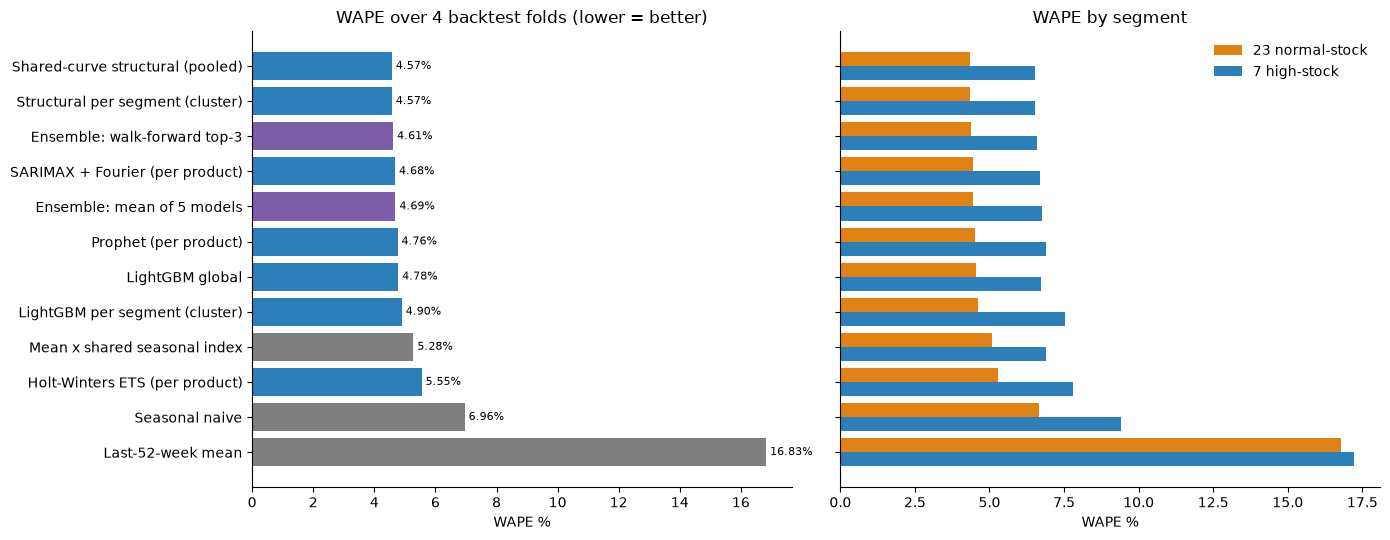

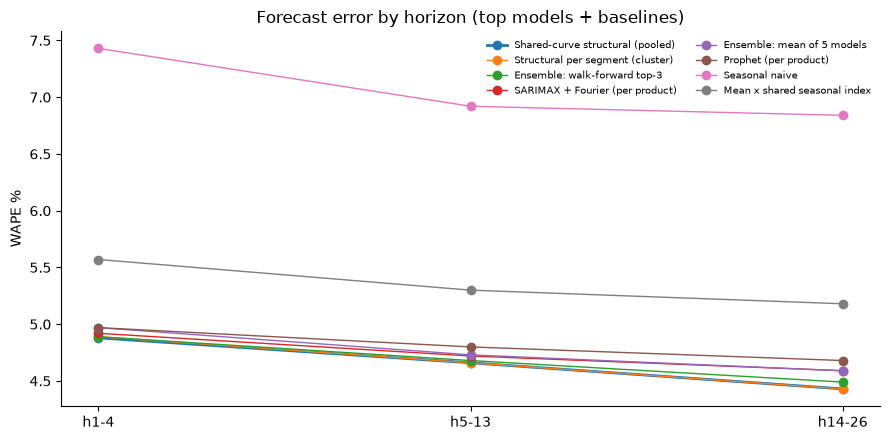

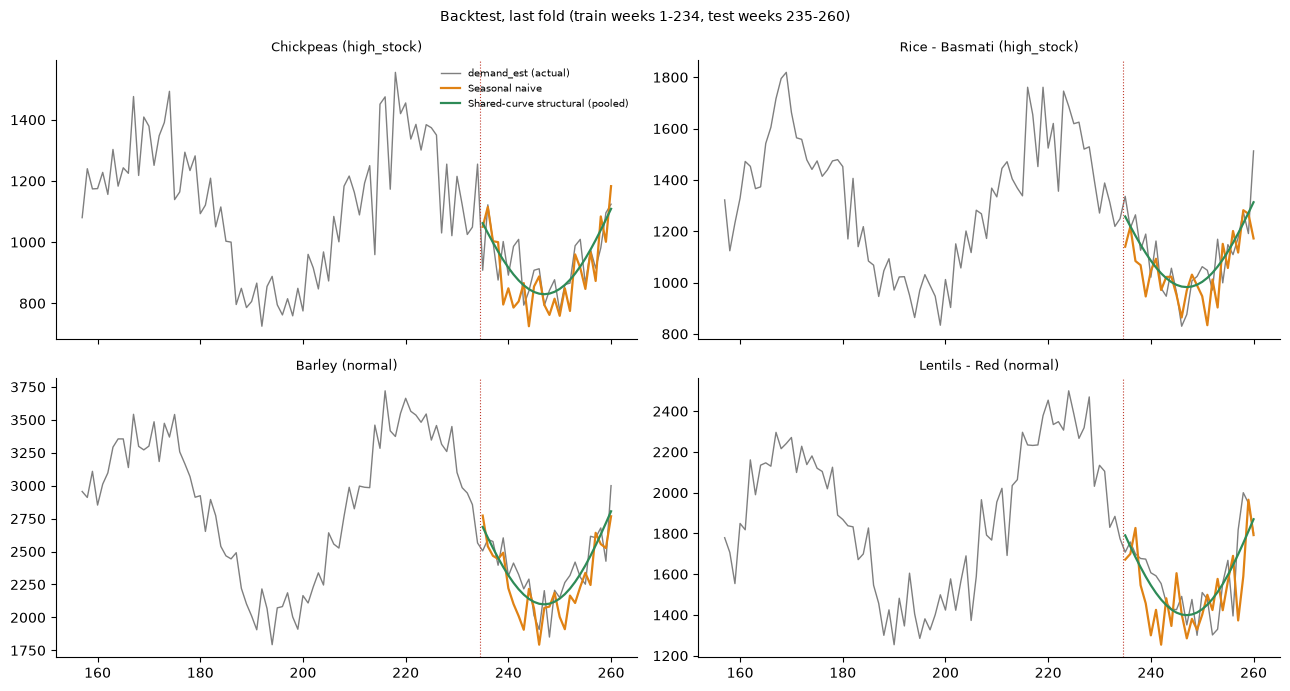

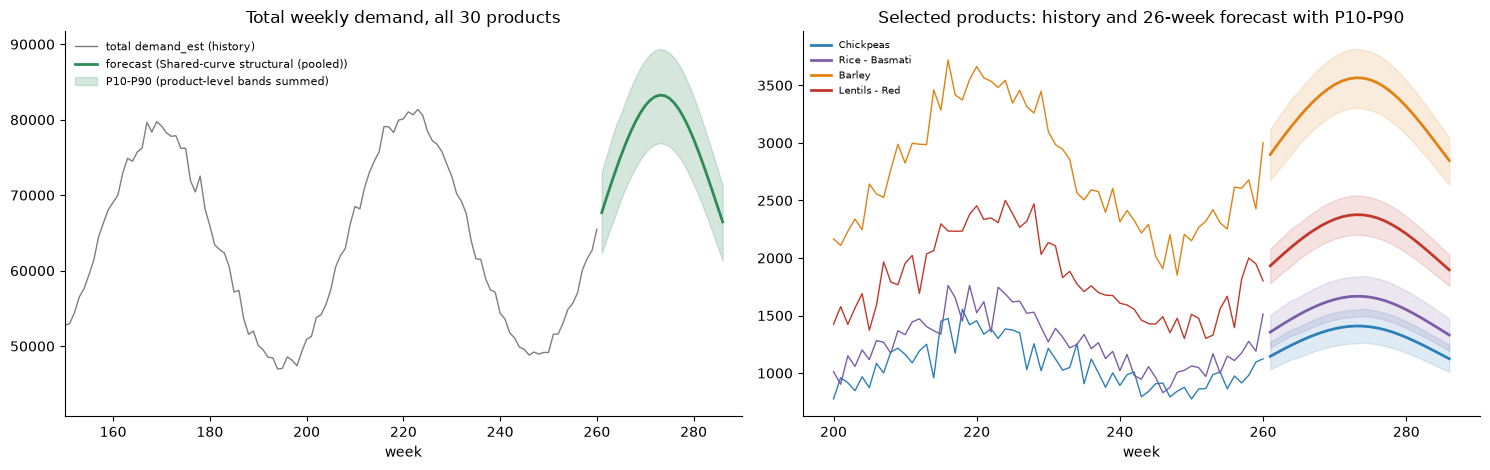

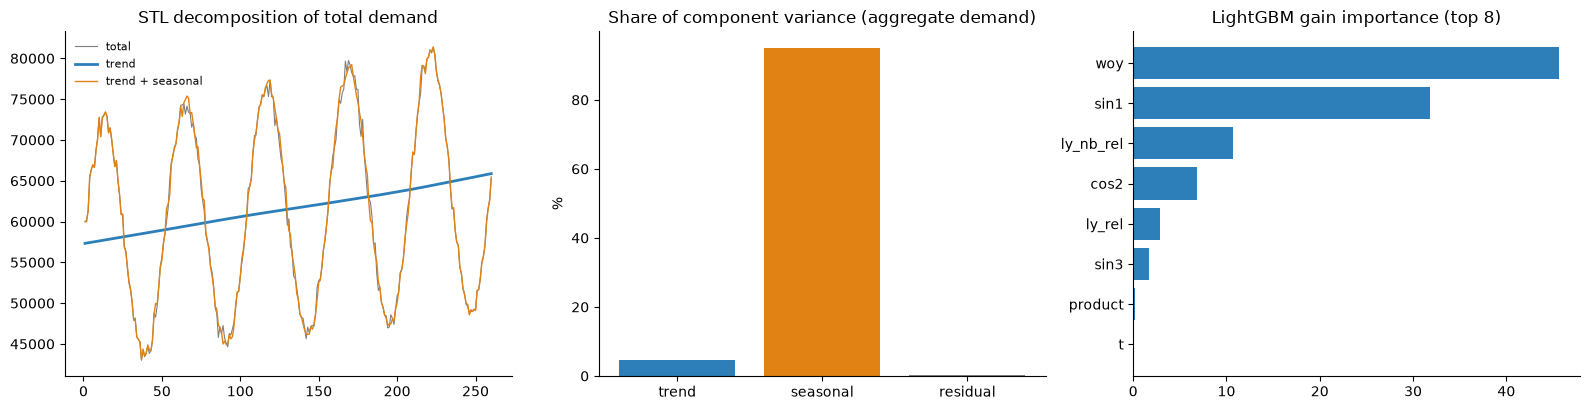

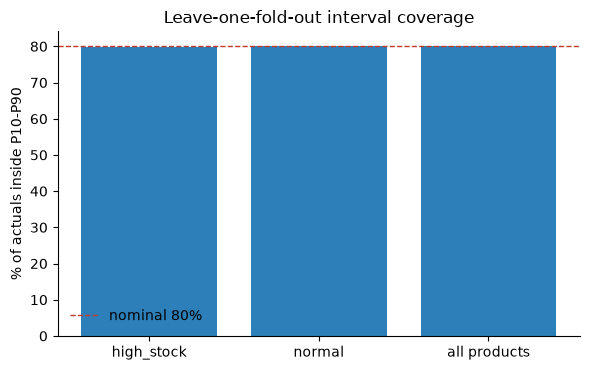

In [19]:
# 1) model comparison: WAPE overall and by segment
order_m = list(comp.index)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
colors = [GREY if m in ("snaive", "mean52", "idx52") else (PURPLE if m.startswith("ens") else BLUE) for m in order_m]
axes[0].barh([LABEL[m] for m in order_m][::-1], (comp.WAPE * 100).values[::-1], color=colors[::-1])
for i, v in enumerate((comp.WAPE * 100).values[::-1]): axes[0].text(v, i, f" {v:.2f}%", va="center", fontsize=8)
axes[0].set_title("WAPE over 4 backtest folds (lower = better)"); axes[0].set_xlabel("WAPE %")
sg = by_seg.WAPE.unstack().loc[order_m[::-1]] * 100; yy = np.arange(len(sg))
axes[1].barh(yy + .2, sg["normal"], .4, color=ORANGE, label="23 normal-stock"); axes[1].barh(yy - .2, sg["high_stock"], .4, color=BLUE, label="7 high-stock")
axes[1].set_title("WAPE by segment"); axes[1].set_xlabel("WAPE %"); axes[1].legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG / f"model_comparison_{VERSION}.png"); plt.show()

# 2) error by horizon
fig, ax = plt.subplots(figsize=(9, 4.5))
hz = by_hz.WAPE.unstack().loc[order_m[:6] + ["snaive", "idx52"]]
for m in hz.index: ax.plot(["h1-4", "h5-13", "h14-26"], hz.loc[m, ["h1-4", "h5-13", "h14-26"]] * 100, marker="o", label=LABEL[m], lw=2 if m == SELECTED else 1)
ax.set_ylabel("WAPE %"); ax.set_title("Forecast error by horizon (top models + baselines)"); ax.legend(frameon=False, fontsize=7, ncol=2)
fig.tight_layout(); fig.savefig(FIG / f"error_by_horizon_{VERSION}.png"); plt.show()

# 3) last backtest fold: actual vs forecast for 4 products
T_ = ORIGINS[-1]
show = [int(np.where(seg == "high_stock")[0][0]), int(np.where(seg == "high_stock")[0][3]), int(np.where(seg == "normal")[0][0]), int(np.where(seg == "normal")[0][8])]
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for ax, j in zip(axes.ravel(), show):
    ax.plot(np.arange(T_ - 78 + 1, T_ + H + 1), Y[T_ - 78:T_ + H, j], color=GREY, lw=1, label="demand_est (actual)")
    for m, c in [("snaive", ORANGE), (SELECTED, GREEN)]:
        ax.plot(np.arange(T_ + 1, T_ + H + 1), FC[m][T_][:, j], color=c, lw=1.6, label=LABEL[m])
    ax.axvline(T_ + .5, color=RED, lw=.8, ls=":"); ax.set_title(f"{names[j]} ({seg[j]})", fontsize=9)
axes[0, 0].legend(frameon=False, fontsize=7); fig.suptitle("Backtest, last fold (train weeks 1-234, test weeks 235-260)", fontsize=10)
fig.tight_layout(); fig.savefig(FIG / f"backtest_examples_{VERSION}.png"); plt.show()

# 4) final forecast: total + products
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].plot(np.arange(1, 261), Y.sum(1), color=GREY, lw=1, label="total demand_est (history)")
axes[0].plot(fut_w, tot.demand_forecast, color=GREEN, lw=2, label=f"forecast ({LABEL[SELECTED]})"); axes[0].fill_between(fut_w, tot.demand_p10, tot.demand_p90, color=GREEN, alpha=.2, label="P10-P90 (product-level bands summed)")
axes[0].set_title("Total weekly demand, all 30 products"); axes[0].legend(frameon=False, fontsize=8); axes[0].set_xlabel("week"); axes[0].set_xlim(150, 290)
for j, c in zip(show, [BLUE, PURPLE, ORANGE, RED]):
    f = final[final.product_id == pids[j]].sort_values("week_id")
    axes[1].plot(np.arange(200, 261), Y[199:260, j], color=c, lw=1); axes[1].plot(f.week_id, f.demand_forecast, color=c, lw=2, label=names[j]); axes[1].fill_between(f.week_id, f.demand_p10, f.demand_p90, color=c, alpha=.15)
axes[1].set_title("Selected products: history and 26-week forecast with P10-P90"); axes[1].legend(frameon=False, fontsize=7); axes[1].set_xlabel("week")
fig.tight_layout(); fig.savefig(FIG / f"final_forecast_{VERSION}.png"); plt.show()

# 5) factor analysis: STL + importance
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(stl_tab.week_id, stl_tab.total_demand, color=GREY, lw=.8, label="total"); axes[0].plot(stl_tab.week_id, stl_tab.trend, color=BLUE, lw=2, label="trend"); axes[0].plot(stl_tab.week_id, stl_tab.trend + stl_tab.seasonal, color=ORANGE, lw=1, label="trend + seasonal"); axes[0].legend(frameon=False, fontsize=8); axes[0].set_title("STL decomposition of total demand")
axes[1].bar(["trend", "seasonal", "residual"], var_share["share_of_component_variance_%"], color=[BLUE, ORANGE, GREY]); axes[1].set_title("Share of component variance (aggregate demand)"); axes[1].set_ylabel("%")
g10 = gain.head(8).iloc[::-1]; axes[2].barh(g10.feature, g10["gain_importance_%"], color=BLUE); axes[2].set_title("LightGBM gain importance (top 8)")
fig.tight_layout(); fig.savefig(FIG / f"factor_analysis_{VERSION}.png"); plt.show()

# 6) interval calibration
fig, ax = plt.subplots(figsize=(6, 3.8)); cv = coverage["coverage (nominal 80%)"] * 100
ax.bar(cv.index, cv.values, color=BLUE); ax.axhline(80, color=RED, ls="--", lw=1, label="nominal 80%"); ax.set_ylabel("% of actuals inside P10-P90"); ax.set_title("Leave-one-fold-out interval coverage"); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG / f"interval_coverage_{VERSION}.png"); plt.show()

## 9. Persist results (SQLite for the dashboard + one Excel workbook)

In [20]:
if DB_OUT.exists():
    DB_OUT.unlink()
con = sqlite3.connect(DB_OUT)
with con:
    fdb = final.copy(); fdb["week_start_date"] = fdb.week_start_date.astype(str)
    fdb.rename(columns={"demand_forecast": "demand_forecast_p50"}).to_sql("fact_demand_forecast", con, index=False)
    comp.reset_index().to_sql("model_comparison", con, index=False)
    fold_metrics.to_sql("backtest_fold_metrics", con, index=False)
    gain.to_sql("feature_importance", con, index=False)
    pd.DataFrame([{"selected_model": SELECTED, "selected_label": LABEL[SELECTED], "horizon_weeks": H, "origins": str(ORIGINS)}]).to_sql("run_info", con, index=False)
con.close()
print("tables written to", DB_OUT.name)

tables written to forecast_results_v1.0.db


In [21]:
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter

c_best = comp.loc[SELECTED]
tt = bt[(bt.model == SELECTED)]
sg_best = by_seg.loc[SELECTED].WAPE
sg_base = by_seg.loc[best_baseline].WAPE
seg_winner = by_seg.WAPE.unstack().idxmin()
summary = pd.DataFrame([
    ("Target", "Reconstructed weekly demand (demand_est), 30 products, horizon 26 weeks (weeks 261-286)", "Stock-censoring removed in preprocessing; observed sales are not demand"),
    ("Validation", f"{len(ORIGINS)} rolling origins {ORIGINS} + final fit on 260 weeks", "All free parameters tuned inside the training window (inner time-series CV / trailing validation block)"),
    ("Approaches compared", f"{len(comp)} models: 3 baselines, ETS, SARIMAX, structural (pooled & per segment), LightGBM (global & per segment), Prophet, 2 ensembles", "Cluster approach = segment-specific fits (7 high-stock vs 23 normal-stock)"),
    ("Selected model", f"{LABEL[SELECTED]}", f"WAPE {100 * c_best.WAPE:.2f}% | MASE {c_best.MASE:.2f} | MAPE {c_best['MAPE_%']:.2f}% | MAE {c_best.MAE:,.0f} units | RMSE {c_best.RMSE:,.0f} | bias {c_best['bias_%']:.2f}%"),
    ("Versus baselines", f"{c_best['skill_vs_best_baseline_%']:.0f}% lower WAPE than the best baseline ({LABEL[best_baseline]}, {100 * comp.loc[best_baseline, 'WAPE']:.2f}%); {c_best['skill_vs_seasonal_naive_%']:.0f}% lower than seasonal naive", f"Paired bootstrap vs best baseline: diff {sig.iloc[1]['WAPE_diff (A-B)']:.4f} (95% CI {sig.iloc[1]['CI95_low']:.4f} .. {sig.iloc[1]['CI95_high']:.4f})"),
    ("Versus runner-up", f"{LABEL[runner_up]} WAPE {100 * comp.loc[runner_up, 'WAPE']:.2f}%", f"Paired bootstrap diff {sig.iloc[0]['WAPE_diff (A-B)']:.4f} (95% CI {sig.iloc[0]['CI95_low']:.4f} .. {sig.iloc[0]['CI95_high']:.4f}); P(selected not better) = {sig.iloc[0]['P(A not better)']:.2f}"),
    ("Truth-cell check", f"WAPE on unconstrained weeks (demand = observed sales): {100 * c_best.WAPE_truth_cells:.2f}%", "Confirms the ranking does not depend on the reconstruction"),
    ("Accuracy caveat", f"Headline WAPE {100 * c_best.WAPE:.1f}% is measured on reconstructed demand, which is smoothed in stock-censored weeks; the honest figure is the truth-cell WAPE {100 * c_best.WAPE_truth_cells:.1f}%", "Quote the truth-cell figure when describing real-world accuracy (high-stock products: 100% truth cells)"),
    ("By segment", f"Selected model WAPE: high-stock {100 * sg_best['high_stock']:.2f}% / normal {100 * sg_best['normal']:.2f}%", f"Best per segment: high-stock = {LABEL[seg_winner['WAPE_high_stock'] if 'WAPE_high_stock' in seg_winner else seg_winner['high_stock']]}, normal = {LABEL[seg_winner['WAPE_normal'] if 'WAPE_normal' in seg_winner else seg_winner['normal']]}"),
    ("Cluster approach", f"struct_seg {100 * comp.loc['struct_seg', 'WAPE']:.2f}% vs struct {100 * comp.loc['struct', 'WAPE']:.2f}%; lgbm_seg {100 * comp.loc['lgbm_seg', 'WAPE']:.2f}% vs lgbm {100 * comp.loc['lgbm', 'WAPE']:.2f}%", "Segment-specific fits vs pooled fits (shape clusters were not used: product profiles are nearly identical)"),
    ("Uncertainty", f"P10-P90 band from backtest ratios; leave-one-fold-out coverage {100 * coverage.loc['all products'].iloc[0]:.0f}% (nominal 80%)", "Used as risk band in Parts 3-4"),
    ("Forecast", f"Total 26-week demand {final.demand_forecast.sum():,.0f} units = {100 * yoy_same_weeks:+.1f}% vs the same 26 weeks a year earlier", f"+{100 * vs_prev_26:.0f}% vs the preceding 26 weeks is the seasonal peak (weeks 1-26 of the cycle), not growth; expected revenue at last-13-week prices {final.expected_revenue.sum():,.0f}"),
    ("Stock scenario", f"If stock follows each product's last-104-week history, {100 * final.expected_lost_units.sum() / final.demand_forecast.sum():.1f}% of forecast demand would not be served (forecast weeks are the seasonal peak, so this is higher than the 39% historical average)", f"Expected revenue then {final.expected_sales_revenue.sum():,.0f}; per product/week in fact_demand_forecast"),
    ("Factors", f"STL on total demand: seasonal strength {var_share.set_index('component').loc['seasonal','strength_(Hyndman)']:.2f}, trend strength {var_share.set_index('component').loc['trend','strength_(Hyndman)']:.2f} (1 = fully explained); growth {growth_tab['growth_%'].mean():.1f}% per year", "Demand is driven by one shared seasonal pattern + product level + slow growth"),
    ("Price sensitivity", f"Within-product price coefficient {elasticity.iloc[0].coefficient:.3f} (95% CI {elasticity.iloc[0].CI95_low:.3f} .. {elasticity.iloc[0].CI95_high:.3f}); COGS {elasticity.iloc[1].coefficient:.3f}", "No measurable price effect in this data -> Part 4 cannot rely on estimated elasticity"),
], columns=["Area", "Result", "Conclusion / detail"])
summary.insert(0, "#", range(1, len(summary) + 1))

assumptions = pd.DataFrame([
    ("F1", "Target", "Reconstructed latent demand (demand_est) from the preprocessing notebook."),
    ("F2", "Horizon", "26 weeks after week 260 on the synthetic calendar (week 1 = 2020-01-06)."),
    ("F3", "No data leakage", "Each model and each tuning step only sees weeks up to the origin; legacy Demand_Forecast is not used as a model input (it does not exist for future weeks)."),
    ("F4", "Hyper-parameters", "Chosen on training data only: inner time-series CV (structural, Prophet), AICc (ETS, SARIMAX), trailing validation block with early stopping (LightGBM)."),
    ("F5", "Metrics", "WAPE is the primary metric (robust to small values); MAPE is reported as required; MASE scales by in-sample seasonal-naive error."),
    ("F6", "Truth cells", "Weeks where stock never limited sales (unconstrained) have demand = observed sales; metrics on them do not depend on the reconstruction."),
    ("F7", "Ensembles", "ens_mean uses 5 pre-declared members; ens_wf picks its top-3 only from earlier folds (walk-forward)."),
    ("F8", "Intervals", "Empirical quantiles of actual/forecast ratios from the selected model's backtests, by segment and horizon bucket."),
    ("F9", "Stock scenario", "Future stock is unknown; expected sales are simulated with each product's own last-104-week stock-availability history."),
    ("F10", "Prices", "Expected revenue uses the last-13-week mean price; no price changes assumed."),
], columns=["#", "Topic", "Assumption"])

sheets = {
    "Summary": summary, "Model_Comparison": comp.reset_index().round(5), "By_Segment": by_seg.reset_index(), "By_Horizon": by_hz.reset_index(),
    "By_Fold": fold_metrics.round(5), "By_Fold_TruthCells": fold_truth.round(5), "Significance": sig.round(5),
    "Tuned_Params": tuned.sort_values(["model", "origin"]), "Run_Times": pd.DataFrame(TIMES),
    "Final_Forecast": final.round(2), "Final_Forecast_Total": tot.reset_index().round(1), "Final_Forecast_All_Models": final_all.round(2),
    "Interval_Quantiles": qtab.reset_index().round(4), "Interval_Coverage": coverage.reset_index().round(4),
    "STL_Components": stl_tab.round(2), "STL_Variance": var_share, "Yearly_Growth": growth_tab.round(3), "Seasonal_Index": seasonal_index.round(4),
    "Price_Cost_Effects": elasticity, "Stock_Demand_Check": stock_corr, "Feature_Importance": gain.round(4),
    "Assumptions": assumptions, "Backtest_Predictions": bt.drop(columns=["err", "hb"]).round(2),
}
with pd.ExcelWriter(XLSX_PATH, engine="openpyxl") as xw:
    for name, t in sheets.items():
        t.to_excel(xw, sheet_name=name[:31], index=False)
wb = load_workbook(XLSX_PATH)
head_fill = PatternFill("solid", fgColor="1F4E79")
for ws in wb.worksheets:
    for cell in ws[1]:
        cell.font = Font(bold=True, color="FFFFFF"); cell.fill = head_fill; cell.alignment = Alignment(horizontal="center", vertical="center")
    ws.freeze_panes = "A2"
    for i, col in enumerate(ws.columns, 1):
        width = max(len(str(c.value)) if c.value is not None else 0 for c in list(col)[:300])
        ws.column_dimensions[get_column_letter(i)].width = min(max(width + 2, 8), 60)
for name, widths in {"Summary": [5, 20, 95, 95], "Assumptions": [6, 22, 140], "Tuned_Params": [14, 10, 130]}.items():
    for col, w in zip("ABCD", widths):
        wb[name].column_dimensions[col].width = w
    for r in wb[name].iter_rows(min_row=2):
        for c in r: c.alignment = Alignment(wrap_text=True, vertical="top")
fs = wb.create_sheet("Figures"); row = 1
for png in sorted(FIG.glob(f"*_{VERSION}.png")):
    fs.cell(row=row, column=1, value=png.name).font = Font(bold=True)
    img = XLImage(str(png)); scale = 700 / img.width; img.width, img.height = 700, int(img.height * scale)
    fs.add_image(img, f"A{row + 1}"); row += int(img.height / 20) + 4
wb.save(XLSX_PATH)
print("Saved:", XLSX_PATH.name, "| sheets:", len(wb.sheetnames))

Saved: forecast_results_v1.0.xlsx | sheets: 24


## 10. Outputs created by this notebook
| File | Purpose |
|---|---|
| `part2_forecasting_v1.0/forecast_results_v1.0.db` | `fact_demand_forecast` (P10/P50/P90, expected revenue, stock scenario), `model_comparison`, `backtest_fold_metrics`, `feature_importance` – input for the dashboard and pricing parts |
| `part2_forecasting_v1.0/forecast_results_v1.0.xlsx` | All results in one workbook (first sheet = Summary) |
| `part2_forecasting_v1.0/figures/*_v1.0.png` | Charts |